In [76]:
import pandas as pd
import requests
import matplotlib.pyplot as plt
import requests 
# Fetch the data.
df = pd.read_csv("https://ourworldindata.org/grapher/children-born-per-woman.csv?v=1&csvType=full&useColumnShortNames=true", storage_options = {'User-Agent': 'Our World In Data data fetch/1.0'})

# Fetch the metadata
metadata = requests.get("https://ourworldindata.org/grapher/children-born-per-woman.metadata.json?v=1&csvType=full&useColumnShortNames=true").json()


In [81]:
import numpy as np


In [82]:
df.describe()



,year,fertility_rate_hist
count,19402.000000,19402.000000
mean,1985.861612,3.936123
std,22.049134,1.991179
min,1891.000000,0.662000
25%,1967.000000,2.138210
50%,1986.000000,3.466000
75%,2005.000000,5.849000
max,2023.000000,8.864000


In [83]:
mexico = df[df['entity'] == 'Mexico']
japan = df[df['entity'] == 'Japan']

In [84]:
mexico.shape


(74, 4)

In [85]:
japan.shape

(77, 4)

In [86]:
anios_mexico = mexico['year'].to_numpy()
tasa_fertilidad_mexico = mexico['fertility_rate_hist'].to_numpy()

anios_japon = japan['year'].to_numpy()
tasa_fertilidad_japon = japan['fertility_rate_hist'].to_numpy()

In [87]:
type(anios_mexico), type(tasa_fertilidad_mexico), type(anios_japon), type(tasa_fertilidad_japon), type(mexico), type(japan)

(numpy.ndarray,
 numpy.ndarray,
 numpy.ndarray,
 numpy.ndarray,
 pandas.DataFrame,
 pandas.DataFrame)

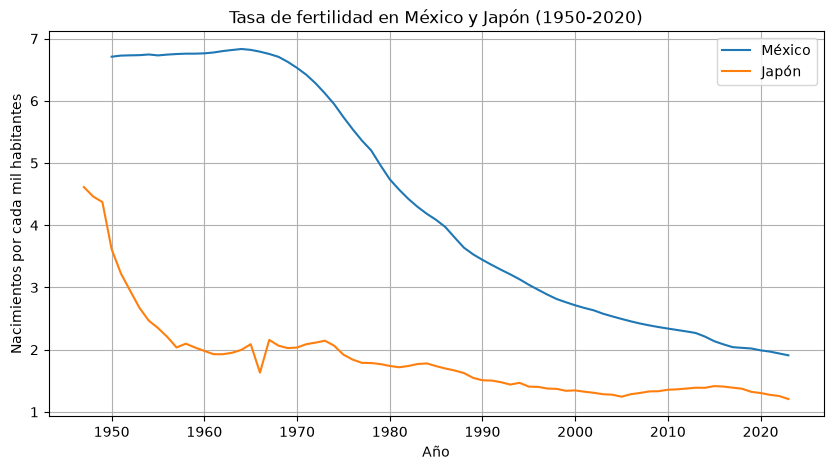

In [88]:
plt.figure(figsize=(10, 5))

plt.plot(anios_mexico, tasa_fertilidad_mexico, label='México')
plt.plot(anios_japon, tasa_fertilidad_japon, label='Japón')

plt.title('Tasa de fertilidad en México y Japón (1950-2020)')
plt.xlabel('Año')
plt.ylabel('Nacimientos por cada mil habitantes')
plt.grid(True)
plt.legend()

plt.show()

In [89]:
plt.figure(figsize=(10, 5))



<Figure size 1000x500 with 0 Axes>

<Figure size 1000x500 with 0 Axes>

In [90]:
mascara_coincidencia_anios = anios_japon >= anios_mexico.min()


In [91]:
mascara_coincidencia_anios

array([False, False, False,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True])

In [92]:
mascara_coincidencia_anios.shape 

(77,)

In [93]:
anios_japon = anios_japon[mascara_coincidencia_anios]


In [94]:
tasa_japon_filtrada = tasa_fertilidad_japon[mascara_coincidencia_anios]

In [95]:
anios_japon.shape

(74,)

In [96]:
diferencia_ex_jp = tasa_fertilidad_mexico - tasa_japon_filtrada

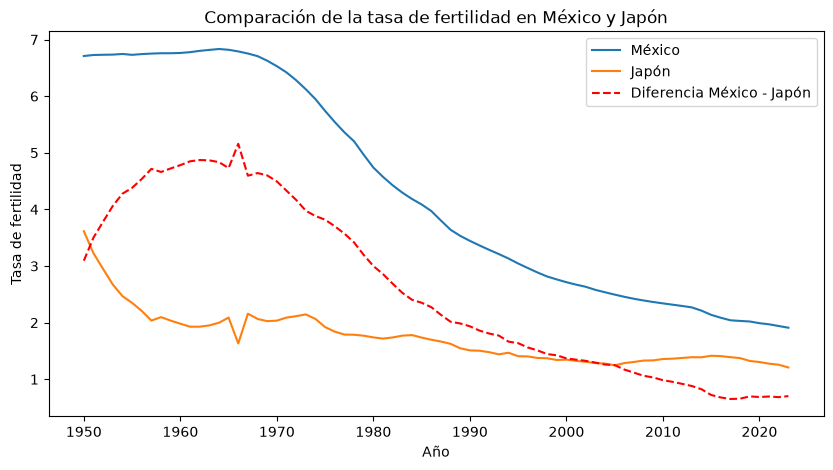

In [97]:
plt.figure(figsize=(10, 5))
plt.plot(anios_mexico, tasa_fertilidad_mexico, label='México')
plt.plot(anios_japon, tasa_japon_filtrada, label='Japón')
plt.plot(anios_mexico, diferencia_ex_jp, label='Diferencia México - Japón', linestyle='--', color='red')

plt.xlabel('Año')
plt.ylabel('Tasa de fertilidad')
plt.title('Comparación de la tasa de fertilidad en México y Japón')
plt.legend()
plt.show()

In [99]:
anios_comunes = np.intersect1d(anios_mexico, anios_japon)

In [100]:
mexico_anios_comunes = mexico[mexico['year'].isin(anios_comunes)]
japon_anios_comunes = japan[japan['year'].isin(anios_comunes)]